# Water Segmentation with U-Net

Input: 128 x 128 x 12 satellite images. Label: binary water mask (1 = water, 0 = background).

Channel order: Coastal aerosol, Blue, Green, Red, NIR, SWIR1, SWIR2, QA band, MERIT DEM, Copernicus DEM, ESA WorldCover, Water occurrence probability.


In [18]:
import os, glob, random, math, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
from scipy.ndimage import uniform_filter, label as cc_label
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

DATA_DIR = "/kaggle/input/datasets/shahdelsawy/sattlite-segmentation/data"
SEED = 42
BATCH_SIZE = 32
LR = 1e-3
ABLATION_EPOCHS = 30
FINAL_EPOCHS = 100
EMA_DECAY = 0.99
PIXEL_SIZE = 30.0  # metres per pixel, only used for slope. Set it to the real resolution of the data.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BANDS = ["Coastal aerosol", "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2",
         "QA band", "MERIT DEM", "Copernicus DEM", "ESA WorldCover", "Water occurrence"]
INDICES = ["NDWI", "MNDWI", "NDVI", "AWEI"]
ANCILLARY = ["Copernicus DEM", "Slope", "Relief", "Water occurrence", "WC water", "WC wetland"]
EXTRA = ["Slope", "Relief", "WC water", "WC wetland"]
BINARY = ["WC water", "WC wetland"]
NAMES = BANDS + INDICES + EXTRA
print(device)
print(DATA_DIR, os.listdir(DATA_DIR))

cuda
/kaggle/input/datasets/shahdelsawy/sattlite-segmentation/data ['labels', 'images']


## 1. Load data

In [19]:
image_paths = sorted(glob.glob(f"{DATA_DIR}/images/*.tif"))
label_dir = f"{DATA_DIR}/labels"
print(len(image_paths), "images")

N, H, W, C = len(image_paths), 128, 128, 12
X = np.zeros((N, C + len(INDICES) + len(EXTRA), H, W), dtype=np.float32)
Y = np.zeros((N, H, W), dtype=np.float32)

for i, path in enumerate(tqdm(image_paths)):
    name = os.path.splitext(os.path.basename(path))[0]
    img = tifffile.imread(path)
    assert img.shape == (H, W, C), img.shape
    X[i, :C] = np.nan_to_num(img.transpose(2, 0, 1))
    mask = np.array(Image.open(f"{label_dir}/{name}.png"))
    Y[i] = mask > 0

print(X.shape, Y.shape, np.unique(Y))

306 images


  0%|          | 0/306 [00:00<?, ?it/s]

(306, 20, 128, 128) (306, 128, 128) [0. 1.]


## 2. Data exploration

,band,min,mean,max
0,Coastal aerosol,-1393.0,396.467987,6568.0
1,Blue,-1169.0,494.621002,9659.0
2,Green,-722.0,822.320007,11368.0
3,Red,-684.0,973.674988,12041.0
4,NIR,-412.0,2090.110107,15841.0
5,SWIR1,-335.0,1964.050049,15252.0
6,SWIR2,-258.0,1351.274048,14647.0
7,QA band,64.0,102.739998,255.0
8,MERIT DEM,-9999.0,141.804001,4245.0
9,Copernicus DEM,8.0,300.740997,4287.0


water pixels: 25.98%, background pixels: 74.02%
images without water: 14.71%


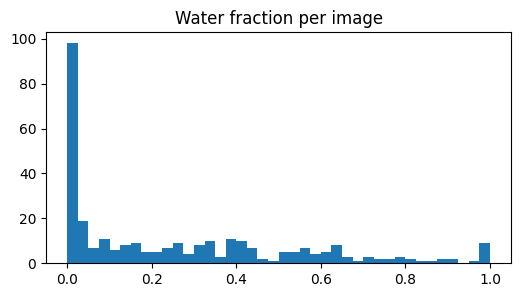

In [20]:
stats = pd.DataFrame({
    "band": BANDS,
    "min": X[:, :C].min(axis=(0, 2, 3)),
    "mean": X[:, :C].mean(axis=(0, 2, 3)),
    "max": X[:, :C].max(axis=(0, 2, 3)),
})
display(stats.round(3))

water_ratio = Y.mean()
print(f"water pixels: {water_ratio:.2%}, background pixels: {1 - water_ratio:.2%}")
per_image = Y.mean(axis=(1, 2))
print(f"images without water: {(per_image == 0).mean():.2%}")

plt.figure(figsize=(6, 3))
plt.hist(per_image, bins=40)
plt.title("Water fraction per image")
plt.show()

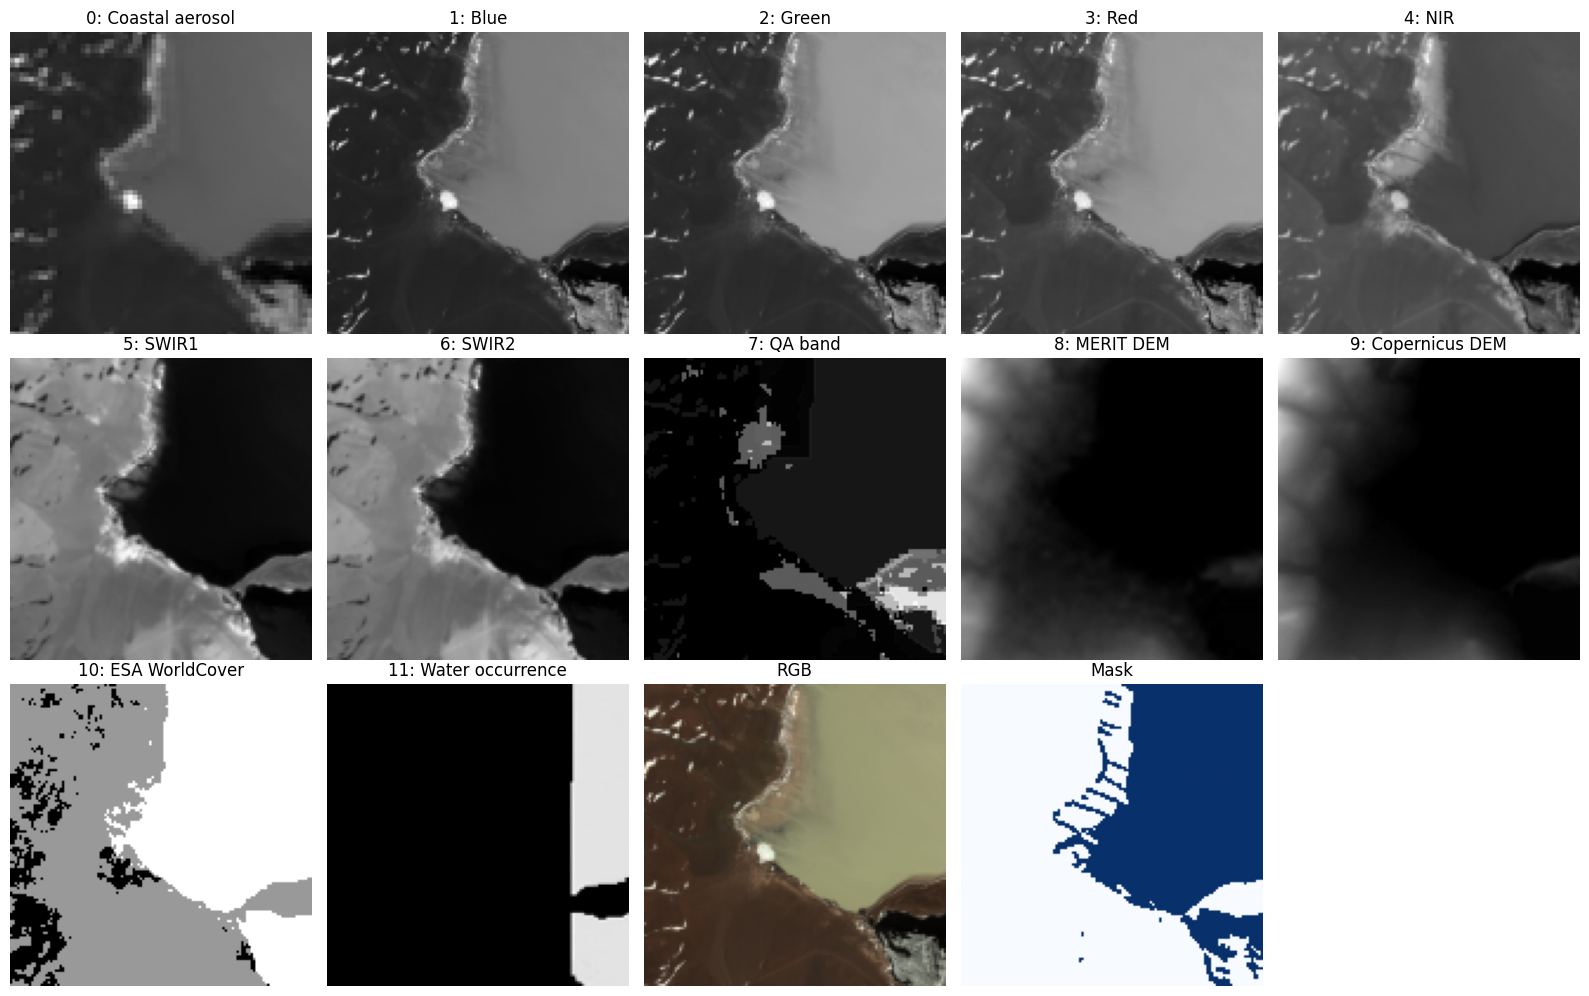

In [21]:
k = int(np.argmin(np.abs(per_image - 0.4)))
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for c in range(C):
    ax = axes.flat[c]
    ax.imshow(X[k, c], cmap="gray")
    ax.set_title(f"{c}: {BANDS[c]}")
    ax.axis("off")
rgb = X[k, [3, 2, 1]].transpose(1, 2, 0)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
axes.flat[12].imshow(rgb)
axes.flat[12].set_title("RGB")
axes.flat[13].imshow(Y[k], cmap="Blues")
axes.flat[13].set_title("Mask")
axes.flat[14].axis("off")
for ax in axes.flat[12:14]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Channel research

| Channel | Behaviour over water | Decision |
|---|---|---|
| Coastal aerosol | Used for aerosol correction, highly correlated with Blue | Drop |
| Blue, Green, Red | Water reflects little visible light, Green is needed for NDWI and MNDWI | Keep |
| NIR | Water absorbs almost all NIR, so water is very dark while vegetation and soil are bright | Keep |
| SWIR1, SWIR2 | Water absorbs SWIR even more strongly, separates water from shadows and built-up areas | Keep |
| QA band | Bit flags for cloud and shadow, not a physical measurement | Drop |
| MERIT DEM, Copernicus DEM | Elevation, water lies in low flat areas. The two DEMs are nearly identical | Keep at most one |
| ESA WorldCover | Categorical land cover classes, not suitable as a numeric input | One-hot water and wetland as 0/1 channels, drop the raw code |
| Water occurrence | Historical water frequency, very informative but may bias against new floods | Test |
| Slope (from DEM) | Water sits on flat ground, so low slope is a strong cue | Add |
| Relief (from DEM) | Height above the local mean (15 x 15 window), water sits below its surroundings | Add |

Spectral indices are added to make the water signal stronger:

- NDWI = (Green - NIR) / (Green + NIR)
- MNDWI = (Green - SWIR1) / (Green + SWIR1)
- NDVI = (NIR - Red) / (NIR + Red)
- AWEI = 4 (Green - SWIR1) - (0.25 NIR + 2.75 SWIR2)

In [22]:
def norm_diff(a, b):
    return (a - b) / (a + b + 1e-6)

blue, green, red, nir, swir1, swir2 = (X[:, i] for i in (1, 2, 3, 4, 5, 6))
X[:, 12] = norm_diff(green, nir)
X[:, 13] = norm_diff(green, swir1)
X[:, 14] = norm_diff(nir, red)
X[:, 15] = 4 * (green - swir1) - (0.25 * nir + 2.75 * swir2)
del blue, green, red, nir, swir1, swir2

### Terrain and land-cover features

Computed before normalization, from the raw DEM and WorldCover values.

- **Slope**: gradient magnitude of the Copernicus DEM, in degrees.
- **Relief**: DEM minus its local mean over a 15 x 15 window, negative where the ground is lower than its surroundings.
- **WC water / WC wetland**: one-hot WorldCover classes (80 = permanent water, 90 and 95 = herbaceous wetland and mangroves). These stay 0/1 and are not standardized.
- `LC` keeps the raw land-cover codes for the per-class analysis at the end.

In [23]:
dem = X[:, BANDS.index("Copernicus DEM")].copy()
gy, gx = np.gradient(dem, PIXEL_SIZE, axis=(1, 2))
X[:, NAMES.index("Slope")] = np.degrees(np.arctan(np.hypot(gx, gy)))
X[:, NAMES.index("Relief")] = dem - uniform_filter(dem, size=(1, 15, 15), mode="reflect")
del dem, gx, gy

LC = np.rint(X[:, BANDS.index("ESA WorldCover")]).astype(np.int16)
print("WorldCover codes:", dict(zip(*np.unique(LC, return_counts=True))))
X[:, NAMES.index("WC water")] = LC == 80
X[:, NAMES.index("WC wetland")] = np.isin(LC, (90, 95))
print("water class share:", (LC == 80).mean().round(4), "| wetland share:", np.isin(LC, (90, 95)).mean().round(4))

WorldCover codes: {np.int16(10): np.int64(1191684), np.int16(20): np.int64(112322), np.int16(30): np.int64(1128291), np.int16(40): np.int64(1839547), np.int16(50): np.int64(123071), np.int16(60): np.int64(70381), np.int16(70): np.int64(27), np.int16(80): np.int64(535069), np.int16(90): np.int64(10222), np.int16(100): np.int64(2890)}
water class share: 0.1067 | wetland share: 0.002


## 4. Split and per-channel normalization

Each channel is normalized separately using statistics of the whole training set (not per image). Values are clipped to the 1st and 99th percentile of the channel, then standardized. Statistics are computed on the training split only. The one-hot channels are left as 0/1.

In [24]:
perm = np.random.permutation(N)
n_train, n_val = int(0.70 * N), int(0.15 * N)
train_idx = perm[:n_train]
val_idx = perm[n_train:n_train + n_val]
test_idx = perm[n_train + n_val:]
print(len(train_idx), len(val_idx), len(test_idx))

channel_stats = []
for c in range(X.shape[1]):
    if NAMES[c] in BINARY:
        channel_stats.append((0, 1, 0, 1))
        continue
    low, high = np.percentile(X[train_idx[:500], c], [1, 99])
    train_values = np.clip(X[train_idx, c], low, high)
    mean, std = train_values.mean(), train_values.std() + 1e-8
    X[:, c] = (np.clip(X[:, c], low, high) - mean) / std
    channel_stats.append((low, high, mean, std))

pd.DataFrame(channel_stats, index=NAMES, columns=["low", "high", "mean", "std"]).to_csv("normalization_stats.csv")
print("sample shape:", X[0, :C].shape)

214 45 47
sample shape: (12, 128, 128)


## 5. Channel importance

,channel,auc
13,MNDWI,0.895
12,NDWI,0.887
4,NIR,0.885
15,AWEI,0.857
5,SWIR1,0.855
14,NDVI,0.837
6,SWIR2,0.835
11,Water occurrence,0.806
10,ESA WorldCover,0.748
8,MERIT DEM,0.728


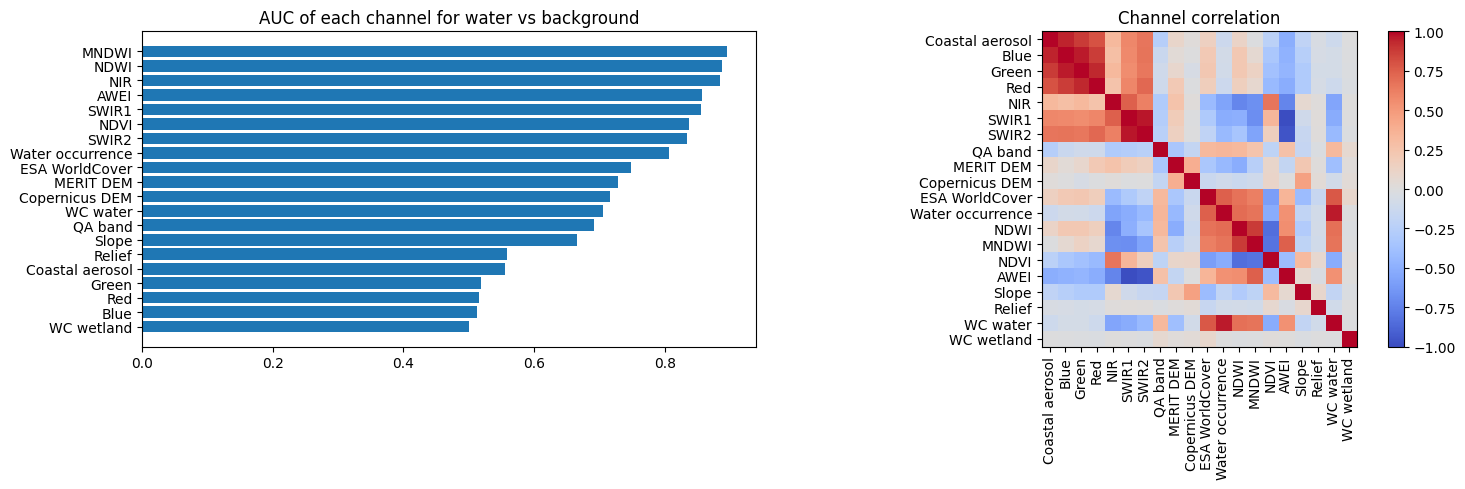

In [25]:
rng = np.random.default_rng(0)
sample_images = rng.choice(train_idx, size=min(300, len(train_idx)), replace=False)
pixel_ids = rng.integers(0, H * W, size=(len(sample_images), 400))

xs = np.concatenate([X[i].reshape(len(NAMES), -1)[:, p] for i, p in zip(sample_images, pixel_ids)], axis=1).T
ys = np.concatenate([Y[i].reshape(-1)[p] for i, p in zip(sample_images, pixel_ids)])

auc = [roc_auc_score(ys, xs[:, c]) for c in range(len(NAMES))]
auc = [max(a, 1 - a) for a in auc]
ranking = pd.DataFrame({"channel": NAMES, "auc": auc}).sort_values("auc", ascending=False)
display(ranking.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(ranking.channel[::-1], ranking.auc[::-1])
axes[0].set_title("AUC of each channel for water vs background")
im = axes[1].imshow(np.corrcoef(xs.T), cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(NAMES)))
axes[1].set_xticklabels(NAMES, rotation=90)
axes[1].set_yticks(range(len(NAMES)))
axes[1].set_yticklabels(NAMES)
axes[1].set_title("Channel correlation")
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

In [26]:
def idx(names):
    return [NAMES.index(n) for n in names]

bands = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]
core = bands + INDICES
FEATURE_SETS = {
    "all_12": list(range(12)),
    "bands_indices": idx(core),
    "bands_indices_dem": idx(core + ["Copernicus DEM"]),
    "bands_indices_dem_occurrence": idx(core + ["Copernicus DEM", "Water occurrence"]),
    "plus_terrain": idx(core + ["Copernicus DEM", "Slope", "Relief", "Water occurrence"]),
    "plus_terrain_landcover": idx(core + ["Copernicus DEM", "Slope", "Relief", "Water occurrence", "WC water", "WC wetland"]),
}
for name, channels in FEATURE_SETS.items():
    print(name, len(channels))

all_12 12
bands_indices 10
bands_indices_dem 11
bands_indices_dem_occurrence 12
plus_terrain 14
plus_terrain_landcover 16


## 6. U-Net with channel attention

In [27]:
class ChannelAttention(nn.Module):
    """Squeeze-and-excitation over the input channels: one learned gate in (0, 1) per channel and image."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 2)), nn.ReLU(),
            nn.Linear(max(channels // reduction, 2), channels), nn.Sigmoid())

    def forward(self, x):
        weights = self.fc(x.mean(dim=(2, 3)))
        return x * weights[:, :, None, None]


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=12, base=32, use_attention=True):
        super().__init__()
        b = base
        self.attn = ChannelAttention(in_channels) if use_attention else nn.Identity()
        self.enc1 = DoubleConv(in_channels, b)
        self.enc2 = DoubleConv(b, 2 * b)
        self.enc3 = DoubleConv(2 * b, 4 * b)
        self.enc4 = DoubleConv(4 * b, 8 * b)
        self.bottleneck = DoubleConv(8 * b, 16 * b)
        self.pool = nn.MaxPool2d(2)

        self.up4 = nn.ConvTranspose2d(16 * b, 8 * b, 2, stride=2)
        self.dec4 = DoubleConv(16 * b, 8 * b)
        self.up3 = nn.ConvTranspose2d(8 * b, 4 * b, 2, stride=2)
        self.dec3 = DoubleConv(8 * b, 4 * b)
        self.up2 = nn.ConvTranspose2d(4 * b, 2 * b, 2, stride=2)
        self.dec2 = DoubleConv(4 * b, 2 * b)
        self.up1 = nn.ConvTranspose2d(2 * b, b, 2, stride=2)
        self.dec1 = DoubleConv(2 * b, b)
        self.head = nn.Conv2d(b, 1, 1)

    def forward(self, x):
        x = self.attn(x)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        x = self.bottleneck(self.pool(e4))

        x = self.dec4(torch.cat([self.up4(x), e4], dim=1))
        x = self.dec3(torch.cat([self.up3(x), e3], dim=1))
        x = self.dec2(torch.cat([self.up2(x), e2], dim=1))
        x = self.dec1(torch.cat([self.up1(x), e1], dim=1))
        return self.head(x)


model = UNet(in_channels=len(NAMES))
print(model(torch.randn(2, len(NAMES), H, W)).shape)
print(sum(p.numel() for p in model.parameters()) / 1e6, "M parameters")

torch.Size([2, 1, 128, 128])
7.768162 M parameters


## 7. Training and metrics

Training uses AdamW with a cosine learning rate schedule (one epoch of warmup), an exponential moving average (EMA) of the weights that is used for validation and checkpointing, and random flips. The loss is BCE plus a Tversky loss (alpha 0.3 for false positives, beta 0.7 for misses). During training the ancillary channels (DEM, slope, relief, water occurrence, WorldCover) are zeroed for 30% of the images. Test-time augmentation (TTA) averages the predictions over the horizontal and vertical flips.

In [28]:
def make_loader(indices, channels, shuffle):
    x = torch.from_numpy(X[np.ix_(indices, channels)])
    y = torch.from_numpy(Y[indices]).unsqueeze(1)
    return DataLoader(TensorDataset(x, y), batch_size=BATCH_SIZE, shuffle=shuffle)


def loss_fn(logits, target, alpha=0.3, beta=0.7):
    bce = F.binary_cross_entropy_with_logits(logits, target)
    prob = torch.sigmoid(logits)
    tp = (prob * target).sum(dim=(1, 2, 3))
    fp = (prob * (1 - target)).sum(dim=(1, 2, 3))
    fn = ((1 - prob) * target).sum(dim=(1, 2, 3))
    tversky = 1 - ((tp + 1) / (tp + alpha * fp + beta * fn + 1)).mean()
    return bce + tversky


def predict_proba(model, x, tta=False):
    """Water probability. With tta=True, average over no flip, horizontal, vertical and both flips."""
    model.eval()
    if not tta:
        return torch.sigmoid(model(x))
    probs = 0
    for dims in ([], [3], [2], [2, 3]):
        t = x.flip(dims) if dims else x
        p = torch.sigmoid(model(t))
        probs = probs + (p.flip(dims) if dims else p)
    return probs / 4


def evaluate(model, loader, threshold=0.5, tta=False):
    model.eval()
    tp = fp = fn = 0
    with torch.no_grad():
        for x, y in loader:
            pred = predict_proba(model, x.to(device), tta) > threshold
            y = y.to(device) > 0.5
            tp += (pred & y).sum().item()
            fp += (pred & ~y).sum().item()
            fn += (~pred & y).sum().item()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    return {
        "iou": tp / (tp + fp + fn + 1e-9),
        "precision": precision,
        "recall": recall,
        "f1": 2 * precision * recall / (precision + recall + 1e-9),
    }


@torch.no_grad()
def predict_set(model, indices, channels, tta=False):
    """Probabilities for the given images, shape (n, H, W), in the order of `indices`."""
    loader = make_loader(indices, channels, False)
    return torch.cat([predict_proba(model, x.to(device), tta).cpu() for x, _ in loader]).squeeze(1).numpy()


class EMA:
    """Exponential moving average of the weights. BatchNorm statistics are copied from the live model."""
    def __init__(self, model, decay=0.99):
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model, step):
        d = min(self.decay, (1 + step) / (10 + step))
        for e, p in zip(self.module.parameters(), model.parameters()):
            e.lerp_(p, 1 - d)
        for e, b in zip(self.module.buffers(), model.buffers()):
            e.copy_(b)


def train(set_name, epochs, use_attention=True):
    channels = FEATURE_SETS[set_name]
    train_loader = make_loader(train_idx, channels, True)
    val_loader = make_loader(val_idx, channels, False)

    torch.manual_seed(SEED)
    model = UNet(in_channels=len(channels), use_attention=use_attention).to(device)
    ema = EMA(model, EMA_DECAY)
    anc = [j for j, c in enumerate(channels) if NAMES[c] in ANCILLARY]
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    total_steps = epochs * len(train_loader)
    warmup = len(train_loader)

    def lr_lambda(step):
        if step < warmup:
            return (step + 1) / warmup
        progress = (step - warmup) / max(1, total_steps - warmup)
        return 0.01 + 0.99 * 0.5 * (1 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    best_iou, best_state, history, step = 0, None, [], 0
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            if random.random() < 0.5:
                x, y = x.flip(3), y.flip(3)
            if random.random() < 0.5:
                x, y = x.flip(2), y.flip(2)
            if anc:
                drop = torch.rand(len(x), 1, 1, 1, device=x.device) < 0.3
                x[:, anc] = x[:, anc] * (~drop)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()
            scheduler.step()
            ema.update(model, step)
            step += 1
            total_loss += loss.item() * len(x)

        metrics = evaluate(ema.module, val_loader)
        history.append({"epoch": epoch, "train_loss": total_loss / len(train_idx), "lr": scheduler.get_last_lr()[0], **metrics})
        print(f"{set_name} | epoch {epoch:02d} | loss {history[-1]['train_loss']:.4f} | val IoU {metrics['iou']:.4f} | val F1 {metrics['f1']:.4f}")
        if metrics["iou"] > best_iou:
            best_iou = metrics["iou"]
            best_state = {k: v.clone() for k, v in ema.module.state_dict().items()}

    ema.module.load_state_dict(best_state)
    return ema.module, pd.DataFrame(history), best_iou

## 8. Which channels and features help?

In [29]:
ablation, trained = {}, {}
for set_name in FEATURE_SETS:
    trained[set_name], _, best_iou = train(set_name, ABLATION_EPOCHS)
    ablation[set_name] = {"channels": len(FEATURE_SETS[set_name]), "val_iou": best_iou}

ablation = pd.DataFrame(ablation).T.sort_values("val_iou", ascending=False)
display(ablation)
best_set = ablation.index[0]
print("best channel set:", best_set)

_, _, iou_no_attn = train(best_set, ABLATION_EPOCHS, use_attention=False)
print(f"{best_set}: with channel attention {ablation.loc[best_set, 'val_iou']:.4f} | without {iou_no_attn:.4f}")

all_12 | epoch 01 | loss 1.3574 | val IoU 0.2694 | val F1 0.4244
all_12 | epoch 02 | loss 1.1096 | val IoU 0.6470 | val F1 0.7857
all_12 | epoch 03 | loss 1.0564 | val IoU 0.6897 | val F1 0.8163
all_12 | epoch 04 | loss 1.0289 | val IoU 0.6883 | val F1 0.8154
all_12 | epoch 05 | loss 1.0005 | val IoU 0.6855 | val F1 0.8134
all_12 | epoch 06 | loss 0.9880 | val IoU 0.6532 | val F1 0.7902
all_12 | epoch 07 | loss 0.9593 | val IoU 0.6611 | val F1 0.7959
all_12 | epoch 08 | loss 0.9308 | val IoU 0.6817 | val F1 0.8108
all_12 | epoch 09 | loss 0.9220 | val IoU 0.6755 | val F1 0.8063
all_12 | epoch 10 | loss 0.9102 | val IoU 0.6770 | val F1 0.8074
all_12 | epoch 11 | loss 0.8953 | val IoU 0.6779 | val F1 0.8080
all_12 | epoch 12 | loss 0.8893 | val IoU 0.6837 | val F1 0.8121
all_12 | epoch 13 | loss 0.8840 | val IoU 0.6855 | val F1 0.8134
all_12 | epoch 14 | loss 0.8653 | val IoU 0.6821 | val F1 0.8110
all_12 | epoch 15 | loss 0.8498 | val IoU 0.6887 | val F1 0.8157
all_12 | epoch 16 | loss 

,channels,val_iou
plus_terrain_landcover,16.0,0.745026
bands_indices,10.0,0.729306
plus_terrain,14.0,0.723643
bands_indices_dem,11.0,0.709439
all_12,12.0,0.704622
bands_indices_dem_occurrence,12.0,0.699049


best channel set: plus_terrain_landcover
plus_terrain_landcover | epoch 01 | loss 1.2676 | val IoU 0.3039 | val F1 0.4662
plus_terrain_landcover | epoch 02 | loss 1.0602 | val IoU 0.6729 | val F1 0.8044
plus_terrain_landcover | epoch 03 | loss 1.0099 | val IoU 0.6778 | val F1 0.8079
plus_terrain_landcover | epoch 04 | loss 0.9793 | val IoU 0.6789 | val F1 0.8087
plus_terrain_landcover | epoch 05 | loss 0.9554 | val IoU 0.6714 | val F1 0.8034
plus_terrain_landcover | epoch 06 | loss 0.9235 | val IoU 0.6682 | val F1 0.8011
plus_terrain_landcover | epoch 07 | loss 0.9113 | val IoU 0.6738 | val F1 0.8051
plus_terrain_landcover | epoch 08 | loss 0.9009 | val IoU 0.6723 | val F1 0.8040
plus_terrain_landcover | epoch 09 | loss 0.8791 | val IoU 0.6805 | val F1 0.8099
plus_terrain_landcover | epoch 10 | loss 0.8572 | val IoU 0.6690 | val F1 0.8017
plus_terrain_landcover | epoch 11 | loss 0.8545 | val IoU 0.6760 | val F1 0.8066
plus_terrain_landcover | epoch 12 | loss 0.8384 | val IoU 0.6798 | v

## 9. Final training

plus_terrain_landcover | epoch 01 | loss 1.2400 | val IoU 0.0000 | val F1 0.0000
plus_terrain_landcover | epoch 02 | loss 1.0292 | val IoU 0.6790 | val F1 0.8088
plus_terrain_landcover | epoch 03 | loss 0.9785 | val IoU 0.6935 | val F1 0.8190
plus_terrain_landcover | epoch 04 | loss 0.9454 | val IoU 0.6953 | val F1 0.8203
plus_terrain_landcover | epoch 05 | loss 0.9182 | val IoU 0.6982 | val F1 0.8223
plus_terrain_landcover | epoch 06 | loss 0.8986 | val IoU 0.6973 | val F1 0.8217
plus_terrain_landcover | epoch 07 | loss 0.8874 | val IoU 0.7029 | val F1 0.8255
plus_terrain_landcover | epoch 08 | loss 0.8573 | val IoU 0.7010 | val F1 0.8242
plus_terrain_landcover | epoch 09 | loss 0.8516 | val IoU 0.7021 | val F1 0.8250
plus_terrain_landcover | epoch 10 | loss 0.8294 | val IoU 0.7012 | val F1 0.8244
plus_terrain_landcover | epoch 11 | loss 0.8178 | val IoU 0.7090 | val F1 0.8297
plus_terrain_landcover | epoch 12 | loss 0.8027 | val IoU 0.7143 | val F1 0.8333
plus_terrain_landcover | epo

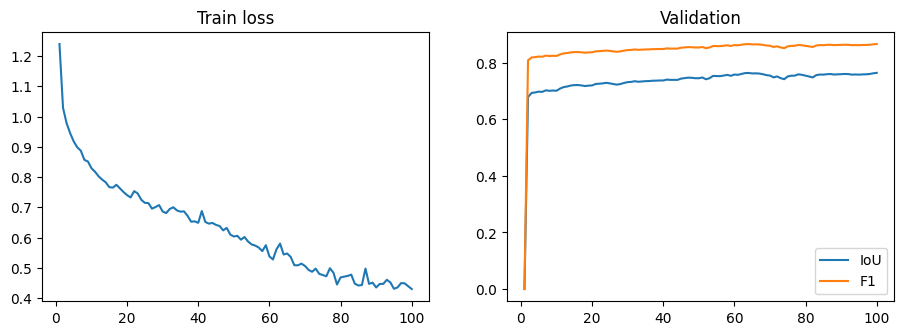

In [30]:
model, history, best_iou = train(best_set, FINAL_EPOCHS)
torch.save(model.state_dict(), "unet_water.pt")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(history.epoch, history.train_loss)
axes[0].set_title("Train loss")
axes[1].plot(history.epoch, history.iou, label="IoU")
axes[1].plot(history.epoch, history.f1, label="F1")
axes[1].set_title("Validation")
axes[1].legend()
plt.show()

## 10. Evaluation

In [31]:
channels = FEATURE_SETS[best_set]
val_loader = make_loader(val_idx, channels, False)
test_loader = make_loader(test_idx, channels, False)
results = pd.DataFrame({
    "validation": evaluate(model, val_loader),
    "test": evaluate(model, test_loader),
    "test + TTA": evaluate(model, test_loader, tta=True),
}).T
results.columns = ["IoU", "Precision", "Recall", "F1"]
display(results.round(4))
print(f"Validation IoU: {results.loc['validation', 'IoU']:.4f}")
results.round(4).to_csv("final_metrics.csv")

,IoU,Precision,Recall,F1
validation,0.7646,0.8413,0.8934,0.8666
test,0.8004,0.8684,0.9109,0.8891
test + TTA,0.7990,0.8670,0.9106,0.8883


Validation IoU: 0.7646


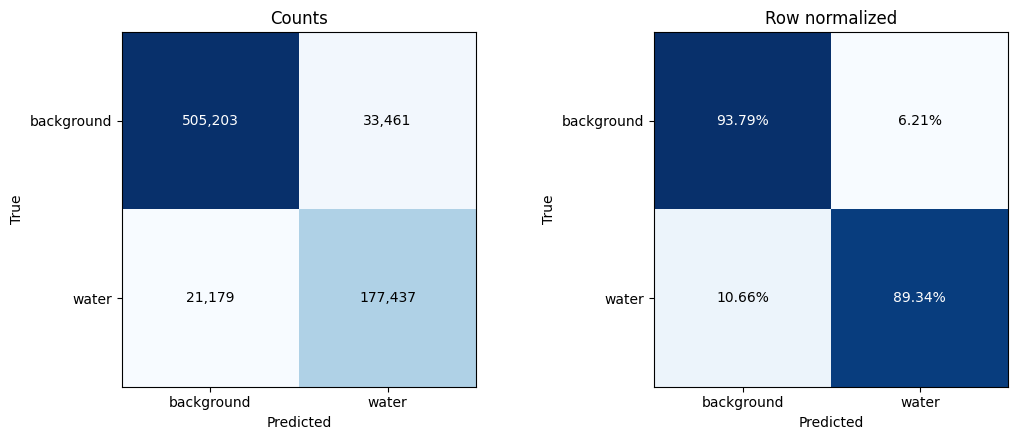

In [32]:
@torch.no_grad()
def confusion_counts(model, loader):
    model.eval()
    cm = np.zeros((2, 2), dtype=np.int64)
    for x, y in loader:
        pred = (model(x.to(device)) > 0).flatten().cpu().numpy().astype(int)
        true = (y > 0.5).flatten().numpy().astype(int)
        cm += np.bincount(true * 2 + pred, minlength=4).reshape(2, 2)
    return cm

cm = confusion_counts(model, val_loader)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
labels = ["background", "water"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, data, title, fmt in ((axes[0], cm, "Counts", "{:,}"), (axes[1], cm_norm, "Row normalized", "{:.2%}")):
    ax.imshow(data, cmap="Blues")
    ax.set_xticks([0, 1], labels)
    ax.set_yticks([0, 1], labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, fmt.format(data[i, j]), ha="center", va="center",
                    color="white" if data[i, j] > data.max() / 2 else "black")
plt.tight_layout()
plt.show()

### Robustness without priors

The test set is scored with all ancillary channels set to zero (no DEM, slope, relief, water occurrence or WorldCover). This shows how much the model still finds from the spectral bands alone, which matters for new floods that the historical layers do not know about.

In [33]:
x = torch.from_numpy(X[np.ix_(test_idx, channels)])
x[:, [j for j, c in enumerate(channels) if NAMES[c] in ANCILLARY]] = 0
no_priors = evaluate(model, DataLoader(TensorDataset(x, torch.from_numpy(Y[test_idx]).unsqueeze(1)), batch_size=BATCH_SIZE))
print("test, ancillary channels zeroed:", {k: round(v, 4) for k, v in no_priors.items()})

test, ancillary channels zeroed: {'iou': 0.7841, 'precision': 0.8499, 'recall': 0.9101, 'f1': 0.879}


### Ensemble and validation threshold

The final model is averaged with the next two best feature-set models from the ablation. The decision threshold is chosen on the validation set only, then applied to the test set.

In [34]:
members = [(model, channels)] + [(trained[s], FEATURE_SETS[s]) for s in ablation.index[1:3]]
ens = lambda ids: np.mean([predict_set(m, ids, ch) for m, ch in members], axis=0)
pv, pt = ens(val_idx), ens(test_idx)
gv, gt = Y[val_idx] > 0.5, Y[test_idx] > 0.5
iou = lambda p, g, t: ((p > t) & g).sum() / ((p > t) | g).sum()
ths = np.arange(0.3, 0.71, 0.05)
best_t = ths[np.argmax([iou(pv, gv, t) for t in ths])]
print(f"members: {[best_set] + list(ablation.index[1:3])}")
print(f"threshold {best_t:.2f} | val IoU {iou(pv, gv, best_t):.4f} | test IoU {iou(pt, gt, best_t):.4f}")

members: ['plus_terrain_landcover', 'bands_indices', 'plus_terrain']
threshold 0.55 | val IoU 0.7583 | test IoU 0.7996


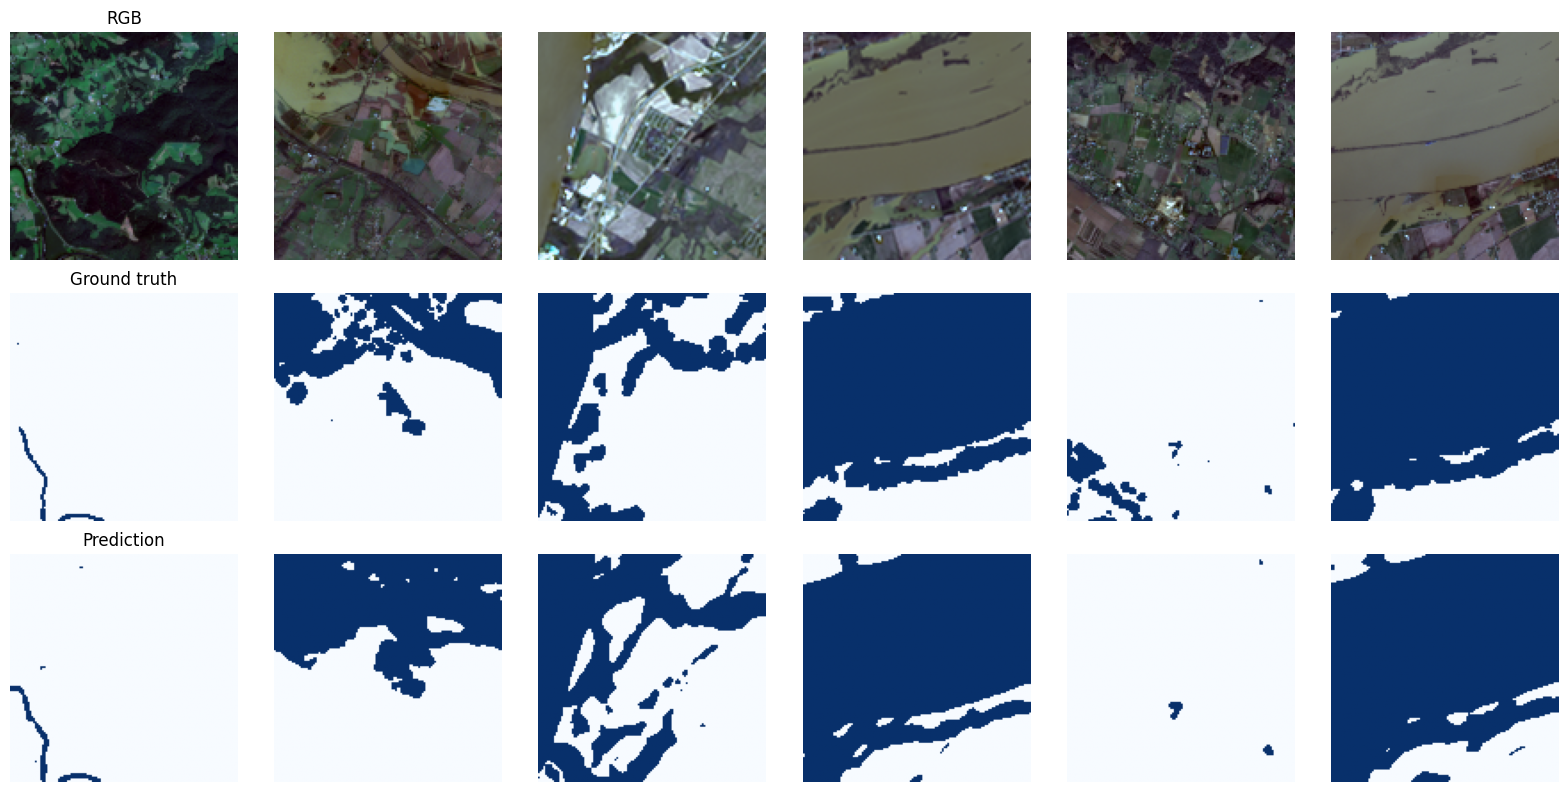

In [35]:
x, y = next(iter(make_loader(test_idx[:6], channels, False)))
with torch.no_grad():
    pred = (predict_proba(model, x.to(device), tta=True) > 0.5).cpu().numpy()

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for j in range(len(x)):
    rgb = X[test_idx[j], [3, 2, 1]].transpose(1, 2, 0)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
    axes[0, j].imshow(rgb)
    axes[1, j].imshow(y[j, 0], cmap="Blues")
    axes[2, j].imshow(pred[j, 0], cmap="Blues")
    for r in range(3):
        axes[r, j].axis("off")
axes[0, 0].set_title("RGB")
axes[1, 0].set_title("Ground truth")
axes[2, 0].set_title("Prediction")
plt.tight_layout()
plt.show()

## 11. Analysis

### Learned channel attention

The attention gate gives every input channel a weight between 0 and 1 for each image. The bars show the mean over the test images, the error bars the spread between images. A low weight means the model suppresses that channel, but the weights are relative and depend on the other channels, so they are read together with the permutation importance below.

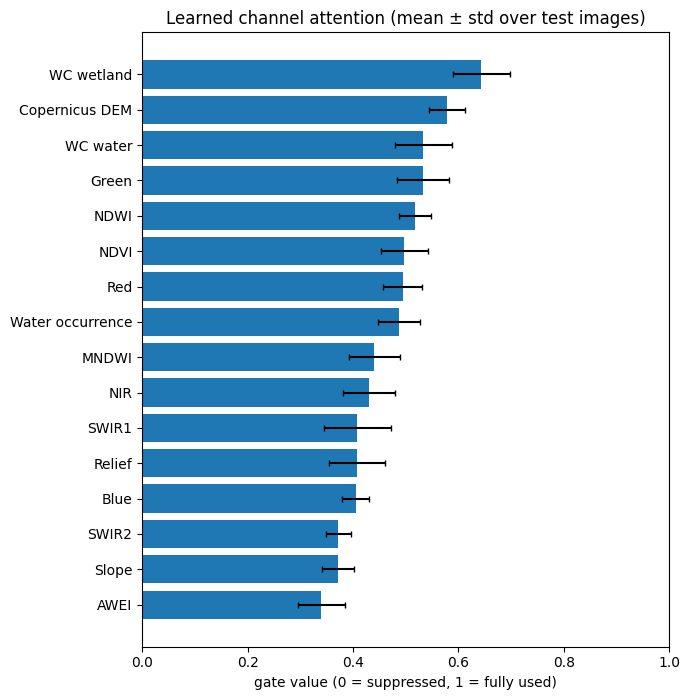

In [36]:
@torch.no_grad()
def attention_weights(model, indices, channels):
    model.eval()
    w = []
    for x, _ in make_loader(indices, channels, False):
        w.append(model.attn.fc(x.to(device).mean(dim=(2, 3))).cpu())
    w = torch.cat(w).numpy()
    return w.mean(0), w.std(0)


w_mean, w_std = attention_weights(model, test_idx, channels)
names = [NAMES[c] for c in channels]
order = np.argsort(w_mean)
plt.figure(figsize=(7, 0.35 * len(channels) + 1.5))
plt.barh([names[i] for i in order], w_mean[order], xerr=w_std[order], capsize=2)
plt.xlim(0, 1)
plt.xlabel("gate value (0 = suppressed, 1 = fully used)")
plt.title("Learned channel attention (mean ± std over test images)")
plt.tight_layout()
plt.show()
pd.DataFrame({"channel": names, "mean_weight": w_mean, "std": w_std}).sort_values("mean_weight", ascending=False).round(3).to_csv("attention_weights.csv", index=False)

### Permutation importance

Each channel is shuffled across the test images, one channel at a time, and the drop in IoU is measured (mean of 3 shuffles). A large drop means the model relies on that channel. Channels that carry the same information, such as the two DEMs or NDWI and MNDWI, can hide each other, so a small drop does not always mean a useless channel.

  0%|          | 0/16 [00:00<?, ?it/s]

test IoU without shuffling: 0.8004


,channel,iou_drop,std
6,NDWI,0.3857,0.0350
1,Green,0.3461,0.0093
3,NIR,0.3460,0.0120
2,Red,0.2611,0.0049
5,SWIR2,0.1921,0.0297
0,Blue,0.1651,0.0058
14,WC water,0.1065,0.0106
13,Water occurrence,0.0625,0.0090
8,NDVI,0.0616,0.0075
4,SWIR1,0.0604,0.0071


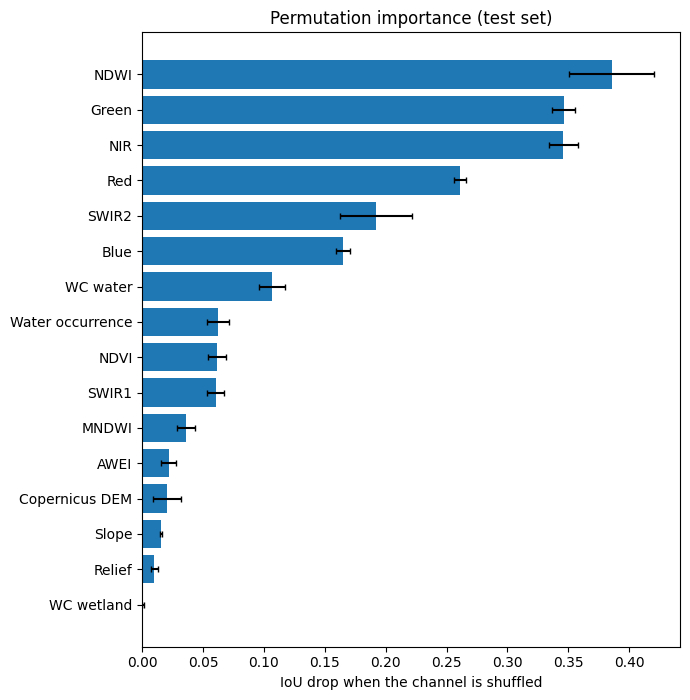

In [37]:
def permutation_importance(model, indices, channels, n_repeats=3, seed=0):
    g = torch.Generator().manual_seed(seed)
    x = torch.from_numpy(X[np.ix_(indices, channels)])
    y = torch.from_numpy(Y[indices]).unsqueeze(1)
    score = lambda x_: evaluate(model, DataLoader(TensorDataset(x_, y), batch_size=BATCH_SIZE))["iou"]
    base = score(x)
    rows = []
    for j, c in enumerate(tqdm(channels)):
        drops = []
        for _ in range(n_repeats):
            xp = x.clone()
            xp[:, j] = x[torch.randperm(len(x), generator=g), j]
            drops.append(base - score(xp))
        rows.append({"channel": NAMES[c], "iou_drop": np.mean(drops), "std": np.std(drops)})
    return base, pd.DataFrame(rows).sort_values("iou_drop", ascending=False)


base_iou, perm_imp = permutation_importance(model, test_idx, channels)
print(f"test IoU without shuffling: {base_iou:.4f}")
display(perm_imp.round(4))
plt.figure(figsize=(7, 0.35 * len(channels) + 1.5))
plt.barh(perm_imp.channel[::-1], perm_imp.iou_drop[::-1], xerr=perm_imp["std"][::-1], capsize=2)
plt.xlabel("IoU drop when the channel is shuffled")
plt.title("Permutation importance (test set)")
plt.tight_layout()
plt.show()
perm_imp.round(4).to_csv("permutation_importance.csv", index=False)

### IoU per land-cover class

Pixels are grouped by their ESA WorldCover class and the water prediction is scored inside each group (with TTA). The false positive rate is the share of non-water pixels of that class that the model calls water.

In [38]:
LC_NAMES = {10: "Tree cover", 20: "Shrubland", 30: "Grassland", 40: "Cropland", 50: "Built-up",
            60: "Bare / sparse", 70: "Snow / ice", 80: "Permanent water", 90: "Herbaceous wetland",
            95: "Mangroves", 100: "Moss / lichen"}

prob_test = predict_set(model, test_idx, channels, tta=True)
pred_test = prob_test > 0.5
gt_test = Y[test_idx] > 0.5
lc_test = LC[test_idx]


def ratio(a, b):
    return a / b if b > 0 else np.nan


rows = []
for code in np.unique(lc_test):
    m = lc_test == code
    tp = (pred_test & gt_test & m).sum()
    fp = (pred_test & ~gt_test & m).sum()
    fn = (~pred_test & gt_test & m).sum()
    rows.append({
        "land cover": LC_NAMES.get(int(code), str(code)),
        "pixels": int(m.sum()),
        "water share": gt_test[m].mean(),
        "IoU": ratio(tp, tp + fp + fn),
        "recall": ratio(tp, tp + fn),
        "false positive rate": ratio(fp, (m & ~gt_test).sum()),
    })
by_class = pd.DataFrame(rows).sort_values("pixels", ascending=False)
display(by_class.round(3))
by_class.round(4).to_csv("iou_per_landcover.csv", index=False)

,land cover,pixels,water share,IoU,recall,false positive rate
3,Cropland,273447,0.314,0.700,0.855,0.102
0,Tree cover,202453,0.189,0.771,0.912,0.043
2,Grassland,154462,0.043,0.413,0.606,0.021
6,Permanent water,83322,1.000,0.998,0.999,0.852
1,Shrubland,25113,0.001,0.000,0.000,0.000
4,Built-up,21163,0.079,0.448,0.674,0.043
5,Bare / sparse,7808,0.041,0.412,0.641,0.024
7,Herbaceous wetland,2280,0.286,0.695,0.765,0.041


### Error maps

The six test images with the lowest IoU (among images that contain water). Red = false positive (predicted water, not water), blue = missed water, grey = correct water. Look here for shadows, clouds, small ponds and thin rivers.

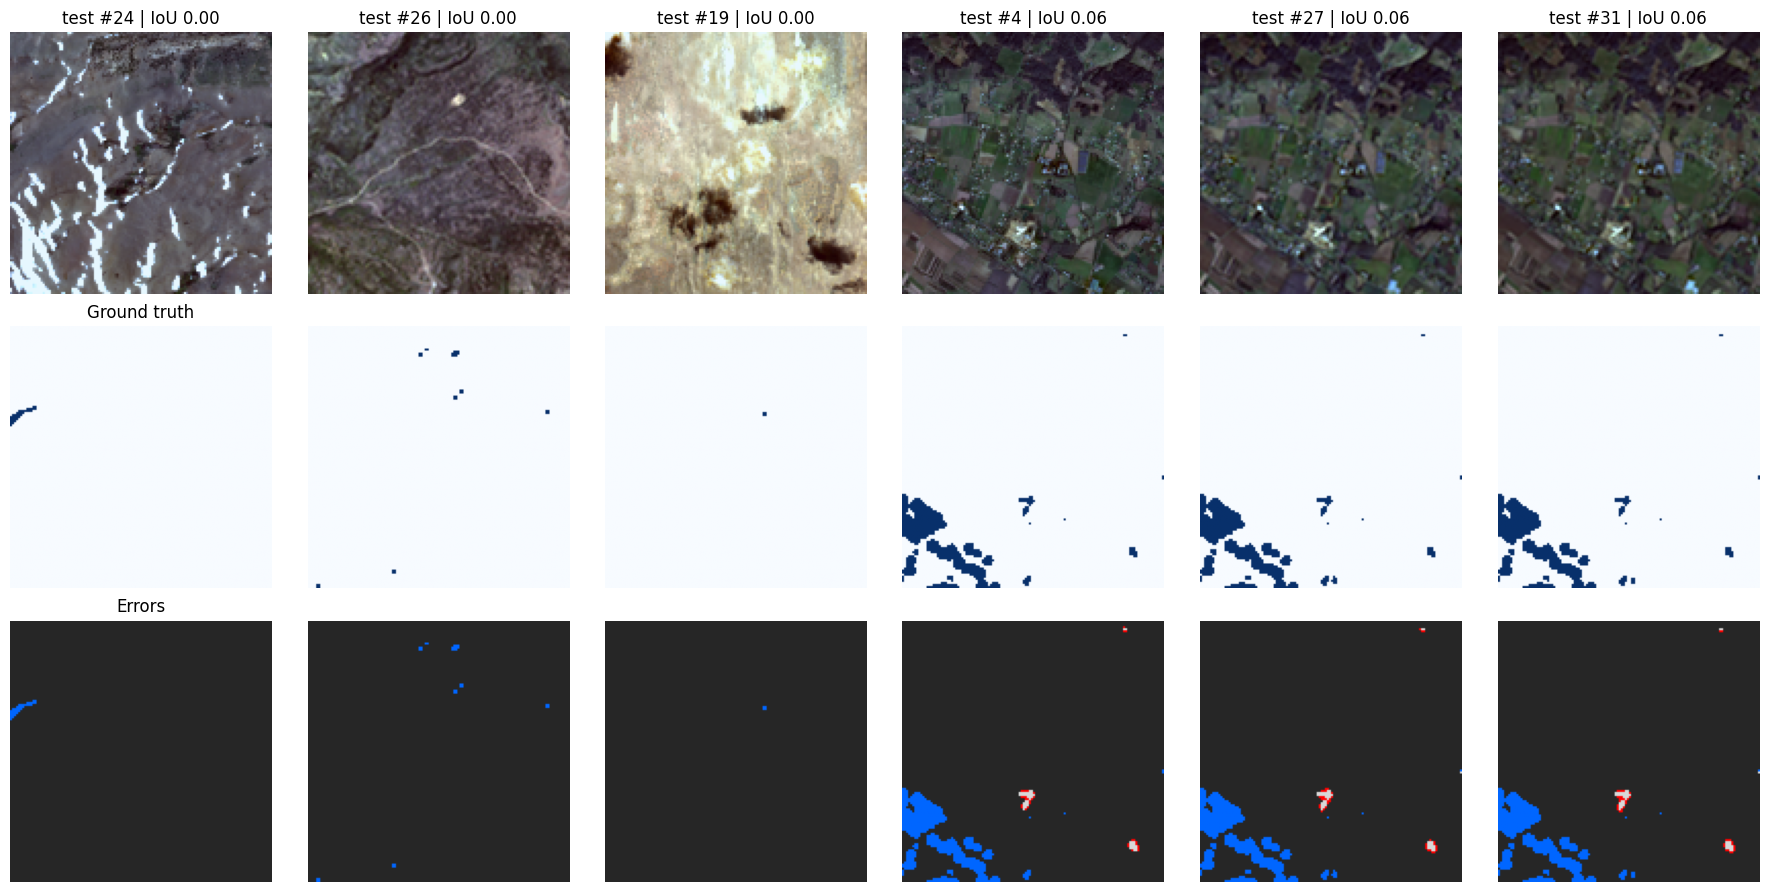

In [39]:
inter = (pred_test & gt_test).sum(axis=(1, 2))
union = (pred_test | gt_test).sum(axis=(1, 2))
img_iou = inter / np.maximum(union, 1)
candidates = np.where(gt_test.sum(axis=(1, 2)) > 0)[0]
worst = candidates[np.argsort(img_iou[candidates])[:6]]

fig, axes = plt.subplots(3, len(worst), figsize=(3 * len(worst), 9))
for j, i in enumerate(worst):
    rgb = X[test_idx[i], [3, 2, 1]].transpose(1, 2, 0)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)
    err = np.full((H, W, 3), 0.15)
    err[pred_test[i] & gt_test[i]] = (0.85, 0.85, 0.85)
    err[pred_test[i] & ~gt_test[i]] = (1.0, 0.0, 0.0)
    err[~pred_test[i] & gt_test[i]] = (0.0, 0.4, 1.0)
    axes[0, j].imshow(rgb)
    axes[0, j].set_title(f"test #{i} | IoU {img_iou[i]:.2f}")
    axes[1, j].imshow(gt_test[i], cmap="Blues")
    axes[2, j].imshow(err)
    for r in range(3):
        axes[r, j].axis("off")
axes[1, 0].set_title("Ground truth")
axes[2, 0].set_title("Errors")
plt.tight_layout()
plt.show()

### Recall by water body size

Each connected water region in the ground truth is scored by the share of its pixels the model found, then grouped by size. This shows whether small ponds and thin rivers are the weak spot.

In [40]:
sizes, recalls = [], []
for i in range(len(gt_test)):
    lab, n = cc_label(gt_test[i])
    for k in range(1, n + 1):
        region = lab == k
        sizes.append(int(region.sum()))
        recalls.append(pred_test[i][region].mean())
regions = pd.DataFrame({"size": sizes, "recall": recalls})
regions["size (px)"] = pd.cut(regions["size"], [0, 10, 50, 200, 1000, H * W],
                              labels=["<=10", "11-50", "51-200", "201-1000", ">1000"])
by_size = regions.groupby("size (px)", observed=True).agg(regions=("size", "size"), mean_recall=("recall", "mean"))
display(by_size.round(3))
by_size.round(4).to_csv("recall_by_size.csv")

,regions,mean_recall
size (px),,
<=10,209,0.344
11-50,116,0.518
51-200,68,0.549
201-1000,32,0.652
>1000,27,0.904
